In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('adult.csv')

print("Original shape:", df.shape)
df = df.replace('?', pd.NA)
df = df.dropna()

print("Cleaned shape:", df.shape)
df.to_csv('adult_cleaned.csv', index=False)

df.head()


Original shape: (32561, 15)
Cleaned shape: (30162, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K


In [13]:
#Task 1

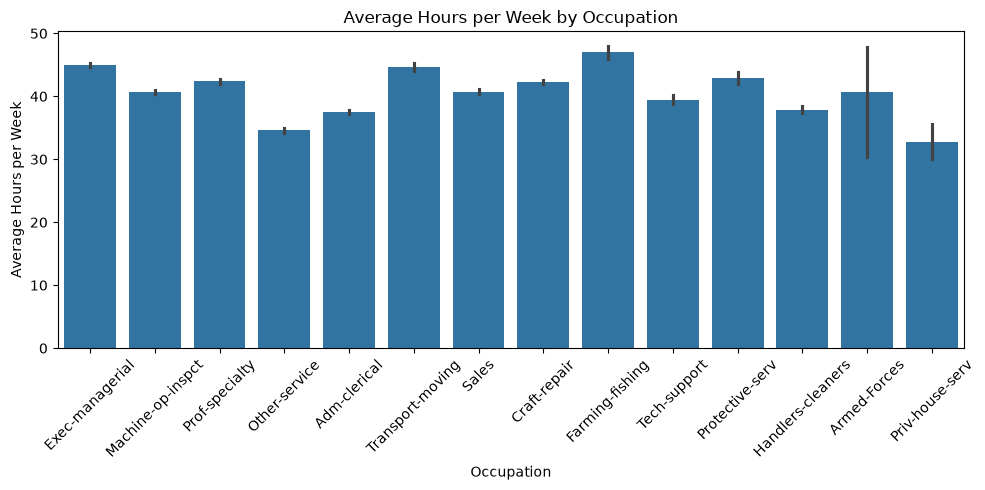

In [14]:
plt.figure(figsize=(10, 5))

sns.barplot(data=df,x='occupation',y='hours.per.week)

plt.title('Average Hours per Week by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Average Hours per Week')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

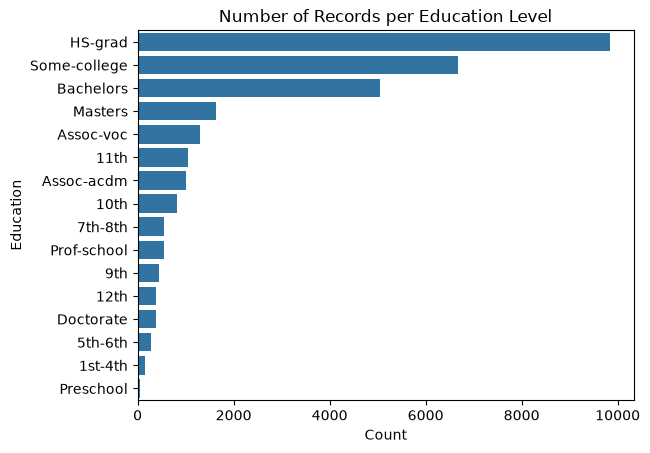

education
HS-grad         9840
Some-college    6678
Bachelors       5044
Masters         1627
Assoc-voc       1307
11th            1048
Assoc-acdm      1008
10th             820
7th-8th          557
Prof-school      542
9th              455
12th             377
Doctorate        375
5th-6th          288
1st-4th          151
Preschool         45
Name: count, dtype: int64


In [18]:
#task 2
order = df['education'].value_counts().index

sns.countplot(data=df, y='education', order=order)

plt.title('Number of Records per Education Level')
plt.xlabel('Count')
plt.ylabel('Education')

plt.show()

print(df['education'].value_counts())

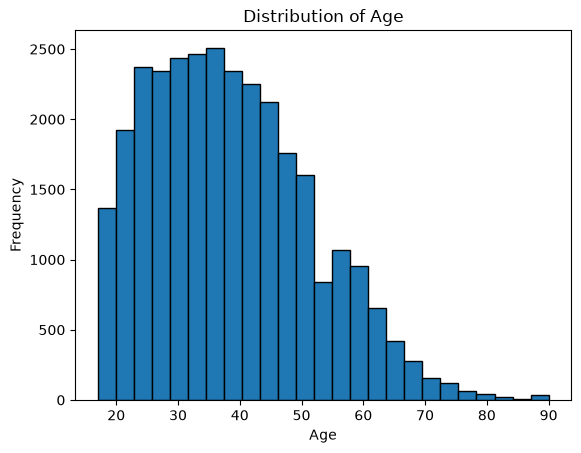

In [21]:
#task 3
plt.hist(df['age'], bins=25, edgecolor='black')

plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

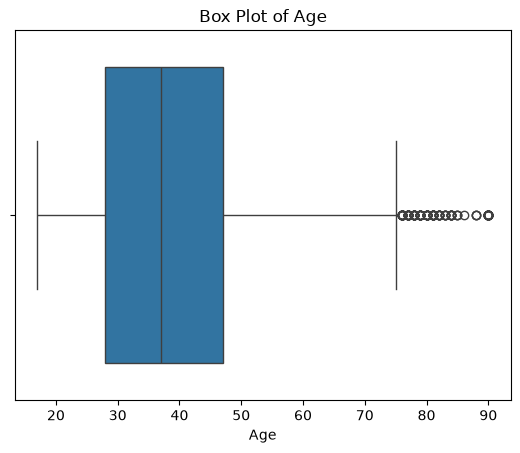

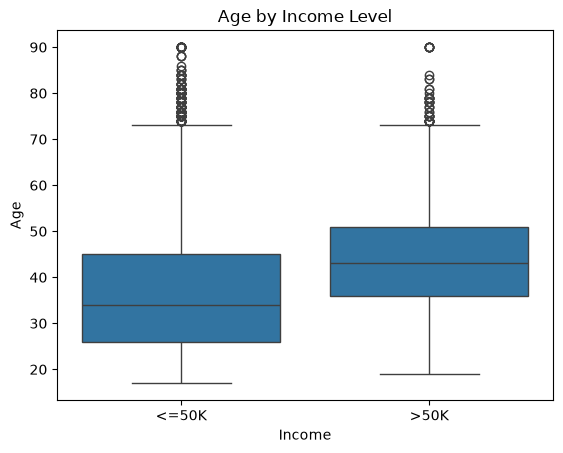

In [23]:
#task 4

sns.boxplot(x=df['age'])

plt.title('Box Plot of Age')
plt.xlabel('Age')

plt.show()

sns.boxplot(data=df, x='income', y='age')

plt.title('Age by Income Level')
plt.xlabel('Income')
plt.ylabel('Age')

plt.show()

In [24]:
#task 5
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_iqr = df[(df['age'] < lower) | (df['age'] > upper)]

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)
print("Lower bound =", lower)
print("Upper bound =", upper)
print("Number of outliers (IQR method):", len(outliers_iqr))


Q1 = 28.0
Q3 = 47.0
IQR = 19.0
Lower bound = -0.5
Upper bound = 75.5
Number of outliers (IQR method): 169


In [25]:
#task 6
df['zscore'] = stats.zscore(df['age'])
outliers_z = df[df['zscore'].abs() > 3]

print("Number of outliers (Z-score method):", len(outliers_z))
print("Number of outliers (IQR method):", len(outliers_iqr))


Number of outliers (Z-score method): 120
Number of outliers (IQR method): 169


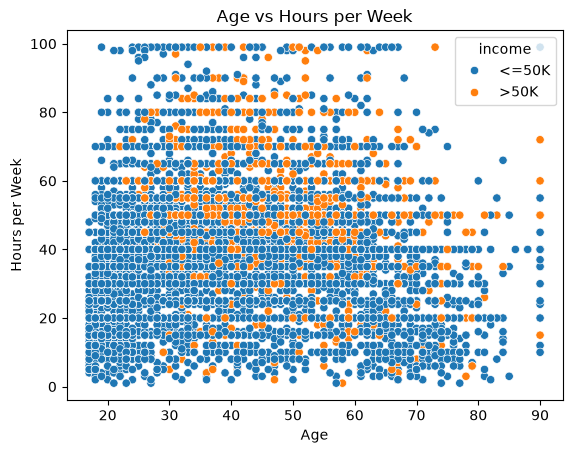

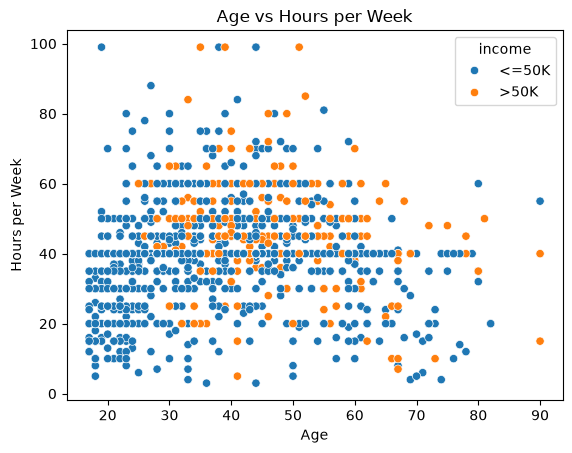

In [30]:
#task 7
sns.scatterplot(data=df,x='age',y='hours.per.week',hue='income')
    
plt.title('Age vs Hours per Week')
plt.xlabel('Age')
plt.ylabel('Hours per Week')

plt.show()

sample_df = df.sample(2000, random_state=1)

sns.scatterplot(data=sample_df, x='age',y='hours.per.week', hue='income')

plt.title('Age vs Hours per Week')
plt.xlabel('Age')
plt.ylabel('Hours per Week')

plt.show()

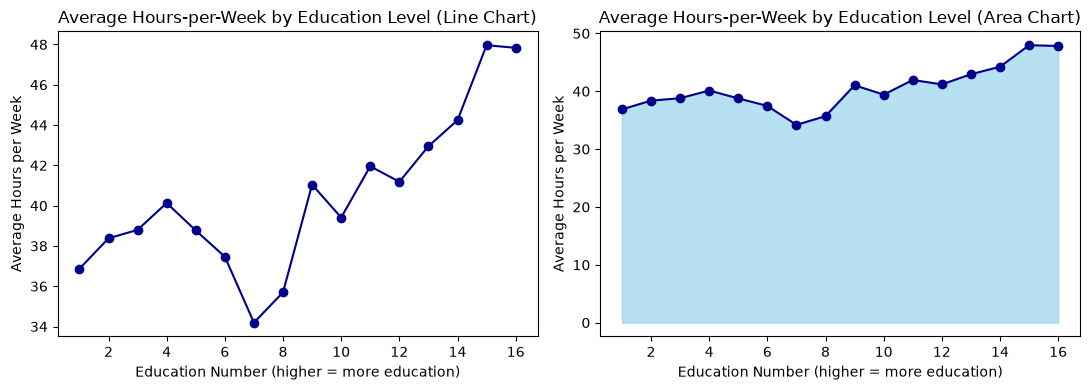

In [36]:
#tTASK 8
avg_hours_by_edu = df.groupby('education.num')['hours.per.week'].mean().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(11,4))

# Line chart
axes[0].plot(avg_hours_by_edu.index, avg_hours_by_edu.values, marker='o', color='darkblue')
axes[0].set_title('Average Hours-per-Week by Education Level (Line Chart)')
axes[0].set_xlabel('Education Number (higher = more education)')
axes[0].set_ylabel('Average Hours per Week')

# Area chart
axes[1].fill_between(avg_hours_by_edu.index, avg_hours_by_edu.values, color='skyblue', alpha=0.6)
axes[1].plot(avg_hours_by_edu.index, avg_hours_by_edu.values, marker='o', color='darkblue')
axes[1].set_title('Average Hours-per-Week by Education Level (Area Chart)')
axes[1].set_xlabel('Education Number (higher = more education)')
axes[1].set_ylabel('Average Hours per Week')

plt.tight_layout()
plt.show()


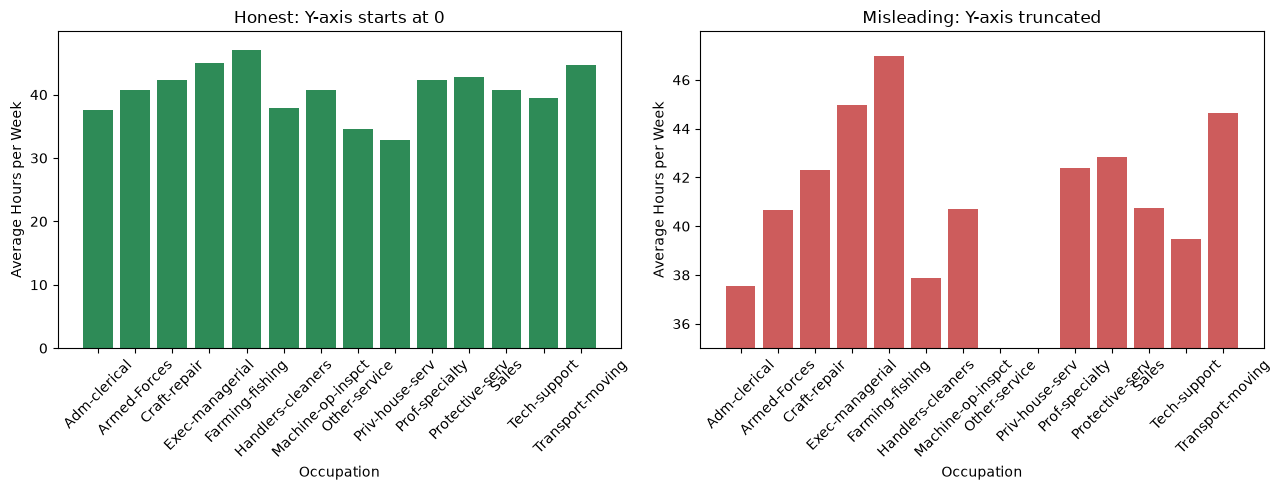

In [35]:
#TASK 9
ig, axes = plt.subplots(1, 2, figsize=(13,5))

# Honest version 
axes[0].bar(avg_hours_by_occ.index, avg_hours_by_occ.values, color='seagreen')
axes[0].set_title('Honest: Y-axis starts at 0')
axes[0].set_xlabel('Occupation')
axes[0].set_ylabel('Average Hours per Week')
axes[0].set_ylim(0, avg_hours_by_occ.max() + 3)
axes[0].tick_params(axis='x', rotation=45)

# Misleading version 
axes[1].bar(avg_hours_by_occ.index, avg_hours_by_occ.values, color='indianred')
axes[1].set_title('Misleading: Y-axis truncated')
axes[1].set_xlabel('Occupation')
axes[1].set_ylabel('Average Hours per Week')
axes[1].set_ylim(35, avg_hours_by_occ.max() + 1)  
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('task9_graphical_integrity.png')
plt.show()